## Problem Statment :

### How do demographic characteristics, parental education levels, socio-economic status, and participation in test preparation programs influence student performance in mathematics, reading, and writing, and what actionable insights can educational institutions derive to improve learning outcomes?

In [1]:
import numpy as np, pandas as pd 

In [2]:
df = pd.read_csv('C:\\Users\\Hp\\Desktop\\StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

no null value is present 

In [7]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [8]:
df[df['math score'] == 100]['math score'].count()

np.int64(7)

Out of 1000 only 7 students score 100 /100

In [9]:
df[df['math score'] == 100]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
149,male,group E,associate's degree,free/reduced,completed,100,100,93
451,female,group E,some college,standard,none,100,92,97
458,female,group E,bachelor's degree,standard,none,100,100,100
623,male,group A,some college,standard,completed,100,96,86
625,male,group D,some college,standard,completed,100,97,99
916,male,group E,bachelor's degree,standard,completed,100,100,100
962,female,group E,associate's degree,standard,none,100,100,100


Details of 100 / 100 scrorer in Mathematics 

In [10]:
df[df['math score'] == 0]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10


Only one student score 00 in maths 

Average score of mathematics 

In [11]:
average_math_score = df["math score"].mean()
print(average_math_score)

66.089


In [12]:
df.columns 

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

Average "Reading Score" 

In [13]:
average_reading__score = df["reading score"].mean()
print(average_reading__score)

69.169


Average " Writing Score "

In [14]:
average_writing__score = df["writing score"].mean()
print(average_writing__score)

68.054


Overall Average 

In [15]:
overall_average = (
    df["math score"].sum() +
    df["reading score"].sum() +
    df["writing score"].sum()
) / (len(df) * 3)
print(overall_average)

67.77066666666667


Highest and Lowest scores of all present criteria 

In [16]:
# Highest scores
print("Highest Scores:")
print("Math:", df["math score"].max())
print("Reading:", df["reading score"].max())
print("Writing:", df["writing score"].max())

# Lowest scores
print("\nLowest Scores:")
print("Math:", df["math score"].min())
print("Reading:", df["reading score"].min())
print("Writing:", df["writing score"].min())

Highest Scores:
Math: 100
Reading: 100
Writing: 100

Lowest Scores:
Math: 0
Reading: 17
Writing: 10


In [17]:
import matplotlib.pyplot as plt

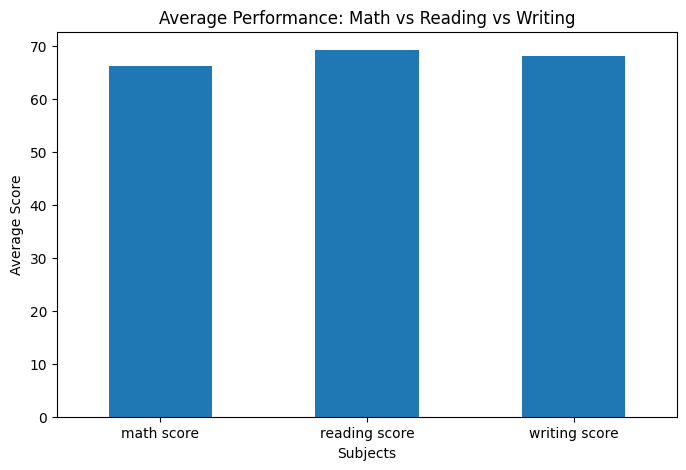

In [18]:
avg_scores = df[["math score", "reading score", "writing score"]].mean()

# Plot
plt.figure(figsize=(8, 5))
avg_scores.plot(kind='bar')

plt.title("Average Performance: Math vs Reading vs Writing")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

Students achieved their highest average score in Reading (≈69), followed by Writing (≈68) and Math (≈66). The narrow gap between subjects indicates balanced overall performance, although Mathematics appears to be the area with the greatest opportunity for improvement.

In [19]:
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

top_10 = df.sort_values(by="average_score", ascending=False).head(10)

print(
    top_10[
        ["gender", "race/ethnicity", "math score",
         "reading score", "writing score", "average_score"]
    ]
)

     gender race/ethnicity  math score  reading score  writing score  \
916    male        group E         100            100            100   
962  female        group E         100            100            100   
458  female        group E         100            100            100   
114  female        group E          99            100            100   
712  female        group D          98            100             99   
179  female        group D          97            100            100   
165  female        group C          96            100            100   
625    male        group D         100             97             99   
685  female        group E          94             99            100   
903  female        group D          93            100            100   

     average_score  
916     100.000000  
962     100.000000  
458     100.000000  
114      99.666667  
712      99.000000  
179      99.000000  
165      98.666667  
625      98.666667  
685      97.666667

Top 10 Students 

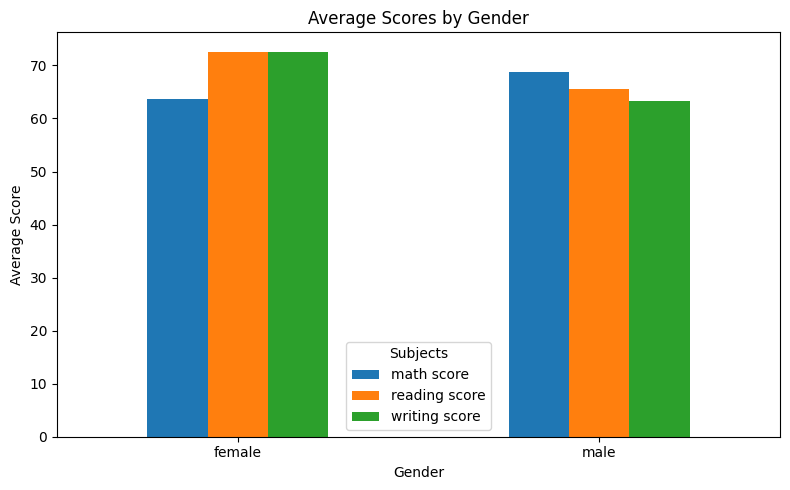

In [20]:
gender_avg = df.groupby("gender")[["math score", "reading score", "writing score"]].mean()

# Create bar chart
gender_avg.plot(kind="bar", figsize=(8, 5))

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subjects")
plt.tight_layout()
plt.show()

Female students demonstrate stronger performance in Reading and Writing, while male students achieve higher scores in Mathematics. The largest gender gap is observed in Writing, where females outperform males by nearly 9 points. These findings indicate distinct subject strengths across genders and may help educators design targeted learning strategies.

In [21]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
import seaborn as sns

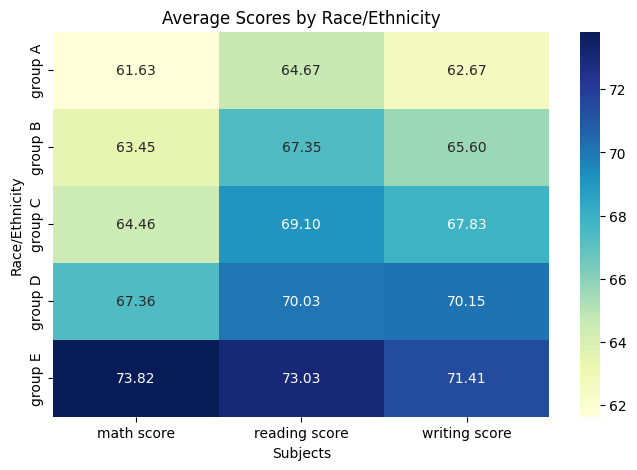

In [23]:
race_avg = df.groupby("race/ethnicity")[
    ["math score", "reading score", "writing score"]
].mean()

# Create heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    race_avg,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Scores by Race/Ethnicity")
plt.xlabel("Subjects")
plt.ylabel("Race/Ethnicity")
plt.show()

The heatmap reveals a progressive increase in academic performance across race/ethnicity groups from A to E, with Group E excelling in all subjects and Reading being the strongest subject for most groups.

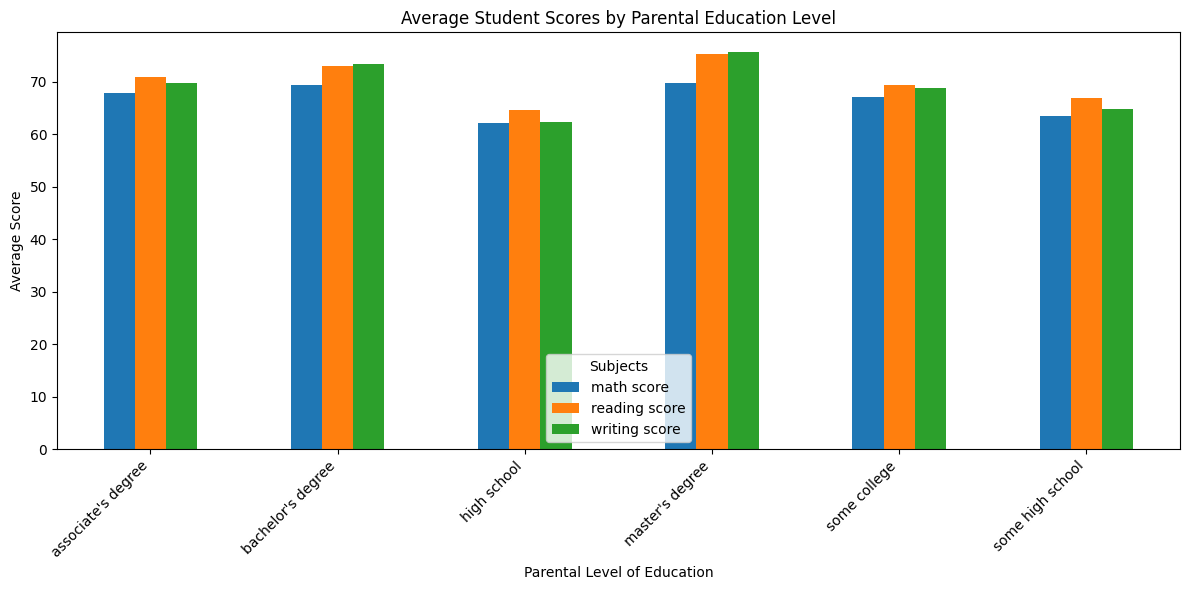

In [24]:
# Calculate average scores by parental education level
parent_edu_avg = df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean()

# Plot grouped bar chart
parent_edu_avg.plot(kind="bar", figsize=(12, 6))

plt.title("Average Student Scores by Parental Education Level")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Subjects")
plt.tight_layout()
plt.show()

### Key Insights from the Chart
##### Students whose parents hold a master's degree achieved the highest average scores across all three subjects, with scores around 70–76, indicating a strong positive relationship between parental education and student performance.
##### Students from bachelor's degree and associate's degree backgrounds also performed well, consistently scoring above the overall average in Math, Reading, and Writing.
##### Students whose parents completed only high school recorded the lowest average scores, particularly in Mathematics, suggesting that lower parental education levels may be associated with lower academic outcomes.
##### eading and Writing scores are higher than Math scores across every parental education category, indicating that students generally perform better in language-related subjects than in Mathematics.
##### Academic performance tends to improve as parental education level increases, with a clear progression from high school and some high school to college degrees and postgraduate education levels.

In [25]:
avg_scores_by_lunch = df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()

print(avg_scores_by_lunch)

              math score  reading score  writing score
lunch                                                 
free/reduced   58.921127      64.653521      63.022535
standard       70.034109      71.654264      70.823256


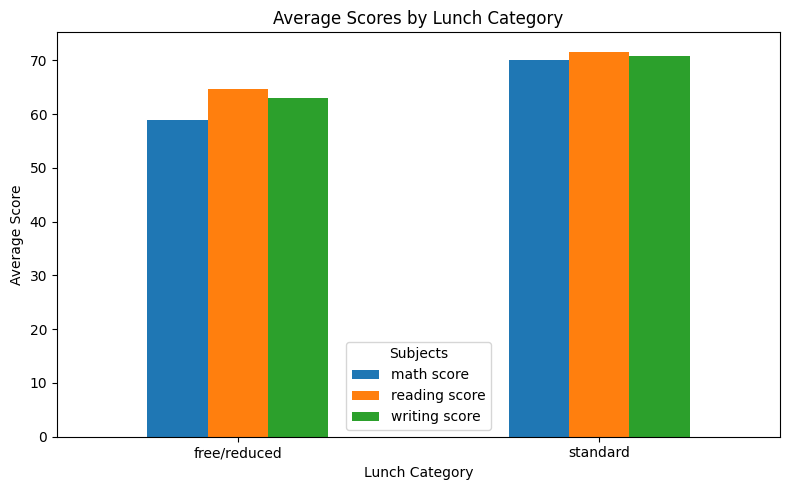

In [26]:
avg_scores_by_lunch.plot(kind='bar', figsize=(8,5))
plt.title('Average Scores by Lunch Category')
plt.xlabel('Lunch Category')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subjects')
plt.tight_layout()
plt.show()

#### Lunch Category "standard" perform well as compare to other categories 

In [27]:
# Calculate average scores
prep_impact = df.groupby('test preparation course')[
    ['math score', 'reading score', 'writing score']
].mean().round(2)

print(prep_impact)

                         math score  reading score  writing score
test preparation course                                          
completed                     69.70          73.89          74.42
none                          64.08          66.53          64.50


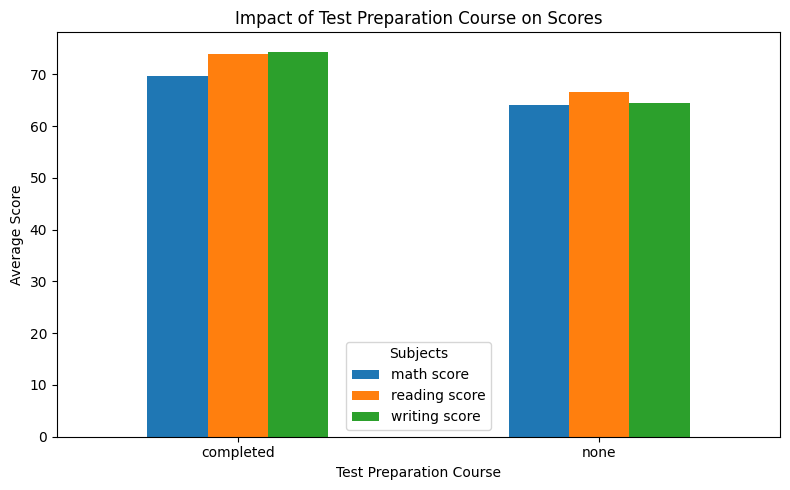

In [28]:
prep_impact.plot(kind='bar', figsize=(8,5))
plt.title('Impact of Test Preparation Course on Scores')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subjects')
plt.tight_layout()
plt.show()

Completing the preparation course appears to have the most substantial positive impact on Writing and Reading scores.

In [29]:
# Select score columns
scores = df[['math score', 'reading score', 'writing score']]

# Calculate correlation matrix
correlation_matrix = scores.corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


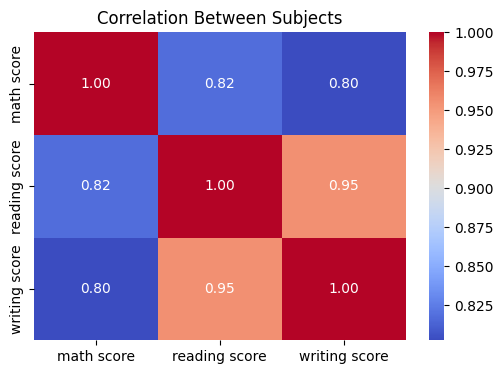

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Subjects')
plt.show()

The heatmap illustrates the Pearson correlation coefficients between student scores in math, reading, and writing. All variables show a strong positive correlation, meaning students who perform well in one subject are highly likely to perform well in the others.

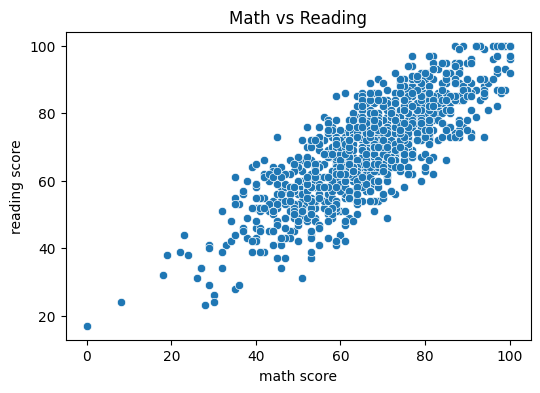

Math vs Reading Correlation: 0.8175796636720544


In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='math score', y='reading score', data=df)
plt.title('Math vs Reading')
plt.show()

print("Math vs Reading Correlation:",
      df['math score'].corr(df['reading score']))

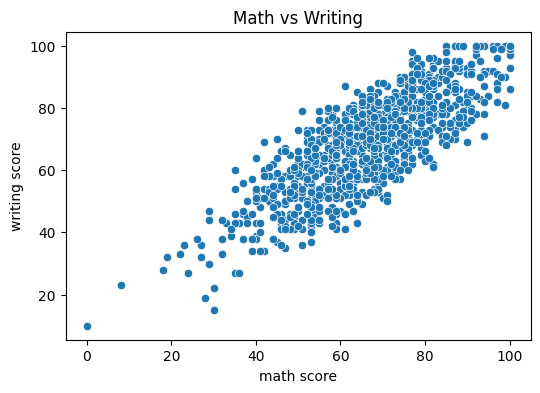

Math vs Writing Correlation: 0.8026420459498085


In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='math score', y='writing score', data=df)
plt.title('Math vs Writing')
plt.show()

print("Math vs Writing Correlation:",
      df['math score'].corr(df['writing score']))

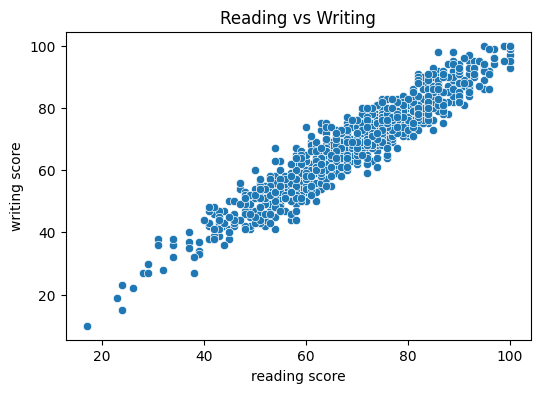

Reading vs Writing Correlation: 0.9545980771462478


In [33]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title('Reading vs Writing')
plt.show()

print("Reading vs Writing Correlation:",
      df['reading score'].corr(df['writing score']))

In [34]:
### For the common Students Performance dataset, you will typically find:

### Reading vs Writing → Very Strong Positive Correlation (~0.95)
### Math vs Reading → Strong Positive Correlation (~0.80)
### Math vs Writing → Strong Positive Correlation (~0.80)

### This indicates that students who perform well in one subject tend to perform well in the others, especially Reading and Writing.

In [35]:
df['Average Score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

# Create Pass/Fail column
df['Result'] = df['Average Score'].apply(
    lambda x: 'Pass' if x >= 40 else 'Fail'
)

# Display first few rows
print(df[['math score', 'reading score', 'writing score', 'Average Score', 'Result']].head())

   math score  reading score  writing score  Average Score Result
0          72             72             74      72.666667   Pass
1          69             90             88      82.333333   Pass
2          90             95             93      92.666667   Pass
3          47             57             44      49.333333   Pass
4          76             78             75      76.333333   Pass


In [36]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,Average Score,Result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,82.333333,82.333333,Pass
2,female,group B,master's degree,standard,none,90,95,93,92.666667,92.666667,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,49.333333,Pass
4,male,group C,some college,standard,none,76,78,75,76.333333,76.333333,Pass


In [37]:
print(df['Result'].value_counts())

Result
Pass    970
Fail     30
Name: count, dtype: int64


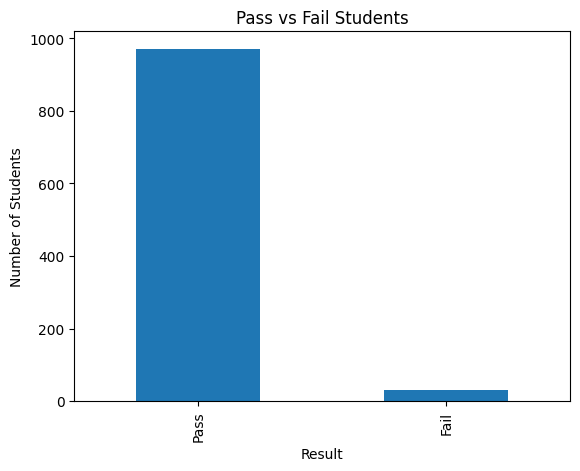

In [38]:
df['Result'].value_counts().plot(kind='bar')
plt.title('Pass vs Fail Students')
plt.xlabel('Result')
plt.ylabel('Number of Students')
plt.show()

In [39]:
overall_pass_percentage = (df['Result'] == 'Pass').mean() * 100

print(f"Overall Pass Percentage: {overall_pass_percentage:.2f}%")

Overall Pass Percentage: 97.00%


In [40]:
pass_rate_gender = (
    df.groupby('gender')['Result']
      .apply(lambda x: (x == 'Pass').mean() * 100)
      .reset_index(name='Pass Percentage')
)

print(pass_rate_gender)

   gender  Pass Percentage
0  female        96.911197
1    male        97.095436


In [41]:
pass_rate_ethnicity = (
    df.groupby('race/ethnicity')['Result']
      .apply(lambda x: (x == 'Pass').mean() * 100)
      .reset_index(name='Pass Percentage')
)

print(pass_rate_ethnicity)

  race/ethnicity  Pass Percentage
0        group A        96.629213
1        group B        95.789474
2        group C        96.865204
3        group D        97.328244
4        group E        98.571429


In [42]:
pass_rate_lunch = (
    df.groupby('lunch')['Result']
      .apply(lambda x: (x == 'Pass').mean() * 100)
      .reset_index(name='Pass Percentage')
)

print(pass_rate_lunch)

          lunch  Pass Percentage
0  free/reduced        93.239437
1      standard        99.069767


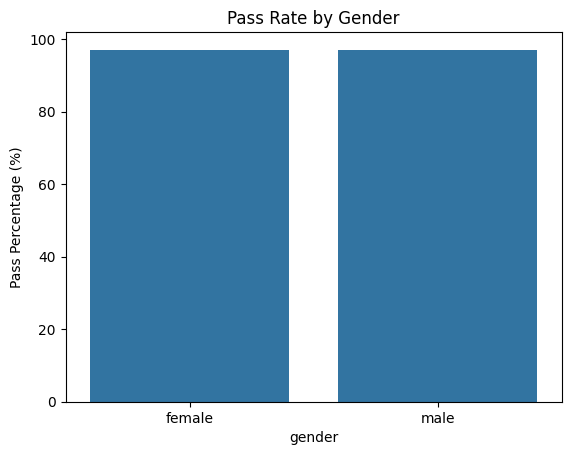

In [43]:


sns.barplot(data=pass_rate_gender,
            x='gender',
            y='Pass Percentage')

plt.title('Pass Rate by Gender')
plt.ylabel('Pass Percentage (%)')
plt.show()

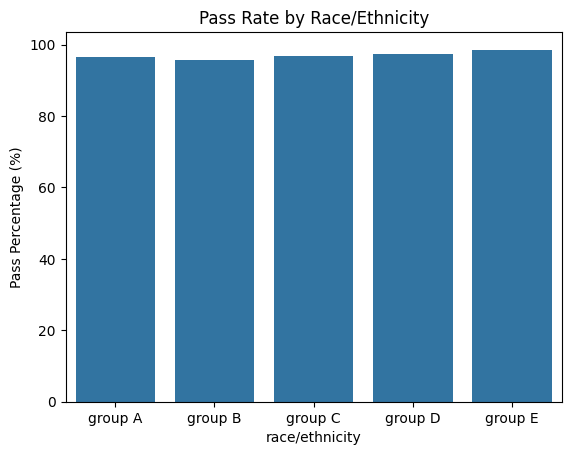

In [44]:
sns.barplot(data=pass_rate_ethnicity,
            x='race/ethnicity',
            y='Pass Percentage')

plt.title('Pass Rate by Race/Ethnicity')
plt.ylabel('Pass Percentage (%)')
plt.show()

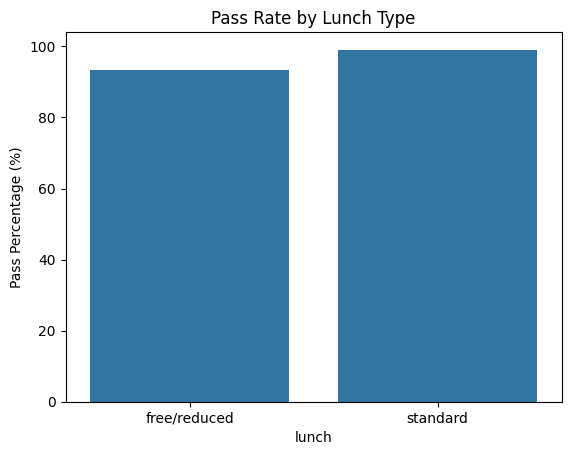

In [45]:
sns.barplot(data=pass_rate_lunch,
            x='lunch',
            y='Pass Percentage')

plt.title('Pass Rate by Lunch Type')
plt.ylabel('Pass Percentage (%)')
plt.show()

In [46]:
print("\nOverall Pass Percentage:")
print(f"{overall_pass_percentage:.2f}%")

print("\nPass Rate by Gender:")
print(pass_rate_gender)

print("\nPass Rate by Race/Ethnicity:")
print(pass_rate_ethnicity)

print("\nPass Rate by Lunch:")
print(pass_rate_lunch)


Overall Pass Percentage:
97.00%

Pass Rate by Gender:
   gender  Pass Percentage
0  female        96.911197
1    male        97.095436

Pass Rate by Race/Ethnicity:
  race/ethnicity  Pass Percentage
0        group A        96.629213
1        group B        95.789474
2        group C        96.865204
3        group D        97.328244
4        group E        98.571429

Pass Rate by Lunch:
          lunch  Pass Percentage
0  free/reduced        93.239437
1      standard        99.069767


In [47]:
def categorize_performance(score):
    if score >= 80:
        return 'High Achiever'
    elif score >= 60:
        return 'Medium Performer'
    else:
        return 'Low Performer'

df['Performance Group'] = df['Average Score'].apply(categorize_performance)

# View results
print(df[['Average Score', 'Performance Group']].head())

   Average Score Performance Group
0      72.666667  Medium Performer
1      82.333333     High Achiever
2      92.666667     High Achiever
3      49.333333     Low Performer
4      76.333333  Medium Performer


In [48]:
performance_counts = df['Performance Group'].value_counts()

print(performance_counts)

Performance Group
Medium Performer    517
Low Performer       285
High Achiever       198
Name: count, dtype: int64


In [49]:
performance_percentage = (
    df['Performance Group'].value_counts(normalize=True) * 100
)

print(performance_percentage)

Performance Group
Medium Performer    51.7
Low Performer       28.5
High Achiever       19.8
Name: proportion, dtype: float64


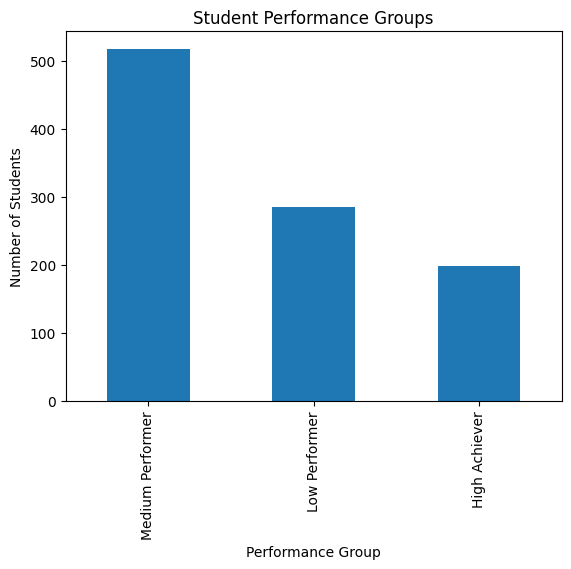

In [50]:
performance_counts.plot(kind='bar')
plt.title('Student Performance Groups')
plt.xlabel('Performance Group')
plt.ylabel('Number of Students')
plt.show()

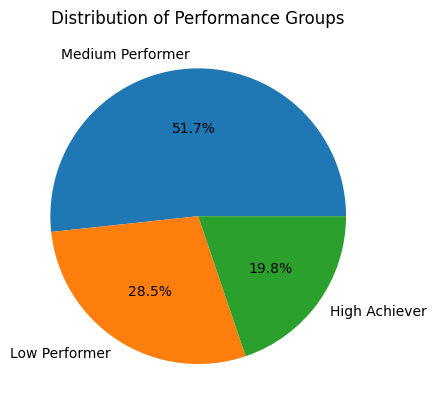

In [51]:
performance_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel=''
)

plt.title('Distribution of Performance Groups')
plt.show()

In [52]:
pd.crosstab(
    df['gender'],
    df['Performance Group'],
    margins=True
)

Performance Group,High Achiever,Low Performer,Medium Performer,All
gender,,,,
female,118,124,276,518
male,80,161,241,482
All,198,285,517,1000


In [53]:
pd.crosstab(
    df['race/ethnicity'],
    df['Performance Group'],
    margins=True
)

Performance Group,High Achiever,Low Performer,Medium Performer,All
race/ethnicity,,,,
group A,11,40,38,89
group B,35,59,96,190
group C,55,97,167,319
group D,53,65,144,262
group E,44,24,72,140
All,198,285,517,1000


In [54]:
pd.crosstab(
    df['lunch'],
    df['Performance Group'],
    margins=True
)

Performance Group,High Achiever,Low Performer,Medium Performer,All
lunch,,,,
free/reduced,39,155,161,355
standard,159,130,356,645
All,198,285,517,1000


In [55]:
df[['math score', 'reading score', 'writing score']].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


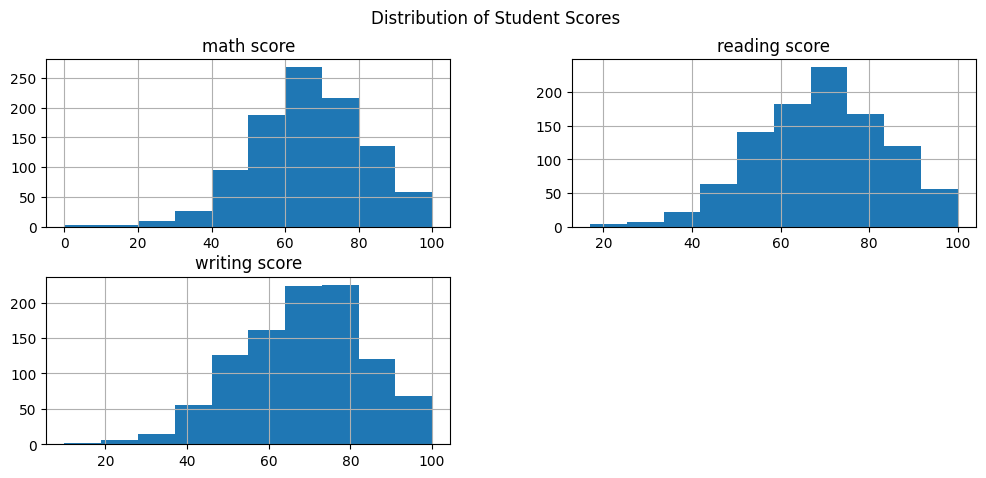

In [56]:
# Histograms
df[['math score', 'reading score', 'writing score']].hist(
    bins=10,
    figsize=(12, 5)
)

plt.suptitle("Distribution of Student Scores")
plt.show()

All distribution shows that all are left skewed graph

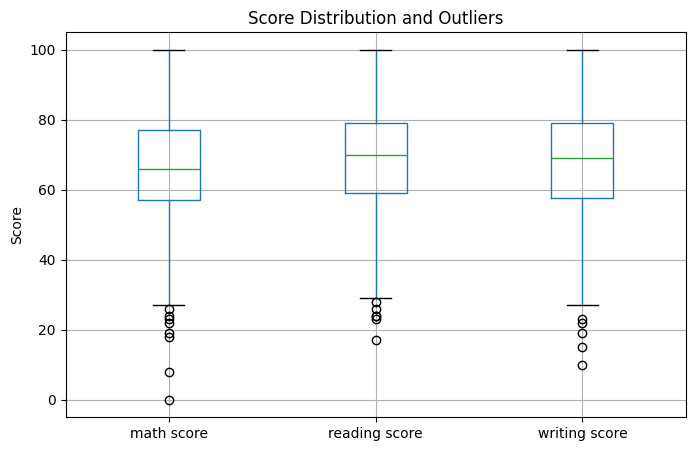

In [57]:
plt.figure(figsize=(8, 5))
df[['math score', 'reading score', 'writing score']].boxplot()
plt.title('Score Distribution and Outliers')
plt.ylabel('Score')
plt.show()

### Based on the box plots for math, reading, and writing scores, here are two key takeaways:
##### Higher Median Performance in Literacy: Students generally performed better in reading and writing than in math, as evidenced by the higher median lines (green) and higher overall box positions for those categories.
##### Presence of Significant Low-End Outliers: All three subjects show a notable number of outliers at the bottom of the scale, particularly in math and writing, where some scores drop as low as 0 and 10, respectively.

In [58]:
# Skewness of scores
skewness = df[['math score', 'reading score', 'writing score']].skew()
print(skewness)

math score      -0.278935
reading score   -0.259105
writing score   -0.289444
dtype: float64


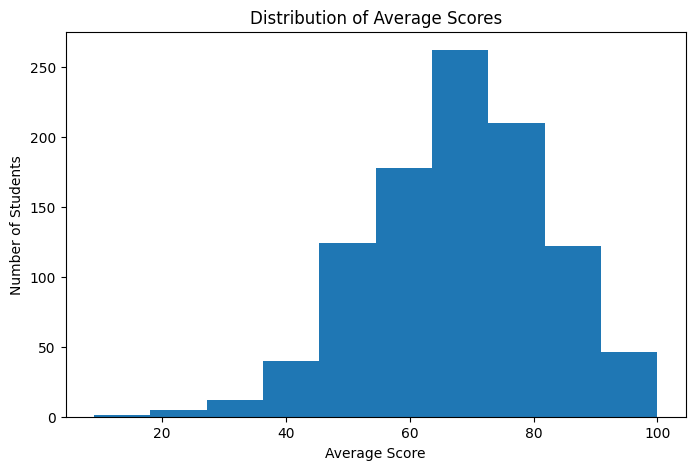

In [59]:
df['Average Score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

plt.figure(figsize=(8,5))
plt.hist(df['Average Score'], bins=10)
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Number of Students')
plt.show()